##1. Load the dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

input_path = "/content/drive/MyDrive/student-risk-ml-project/data/processed/student_ml_ready.csv"

df = pd.read_csv(input_path)

print("Shape:", df.shape)
df.head()

Shape: (649, 44)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,At_Risk
0,0,0,18,1,1,0,4,4,2,2,...,0,1,1,0,0,0,0,1,0,0
1,0,0,17,1,1,1,1,1,1,2,...,0,0,1,0,0,0,1,0,0,0
2,0,0,15,1,0,1,1,1,1,2,...,0,0,0,0,1,0,0,1,0,0
3,0,0,15,1,1,1,4,2,1,3,...,1,0,0,1,0,0,0,1,0,0
4,0,0,16,1,1,1,3,3,1,2,...,0,0,0,1,0,0,1,0,0,0


##2. Separate features and target

In [3]:
X = df.drop(columns=["At_Risk"])
y = df["At_Risk"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (649, 43)
y shape: (649,)


##3. Use the same train/test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (519, 43)
X_test : (130, 43)


##4. Train the Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, n_jobs=-1,
                       random_state=42)

##5. Make predictions

In [6]:
y_pred = rf_model.predict(X_test)

In [7]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

##6. Evaluate the model

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.8461538461538461
Precision: 0.5
Recall   : 0.05
F1 Score : 0.09090909090909091
ROC-AUC  : 0.8227272727272726


In [9]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       110
           1       0.50      0.05      0.09        20

    accuracy                           0.85       130
   macro avg       0.68      0.52      0.50       130
weighted avg       0.80      0.85      0.79       130



##7. Confusion matrix

In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[109   1]
 [ 19   1]]


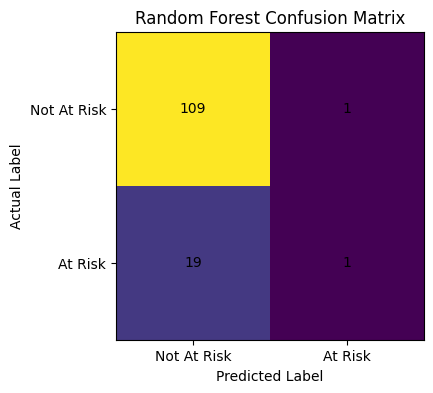

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Not At Risk", "At Risk"])
plt.yticks([0, 1], ["Not At Risk", "At Risk"])

plt.show()

##8. Check overfitting

In [12]:
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.9749518304431599
Testing Accuracy : 0.8461538461538461


##9. Feature importance

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
10,failures,0.128376
0,school,0.059519
25,absences,0.054210
16,higher,0.052484
19,famrel,0.049145
20,freetime,0.038616
23,Walc,0.036806
21,goout,0.036704
7,Fedu,0.035810
2,age,0.035037


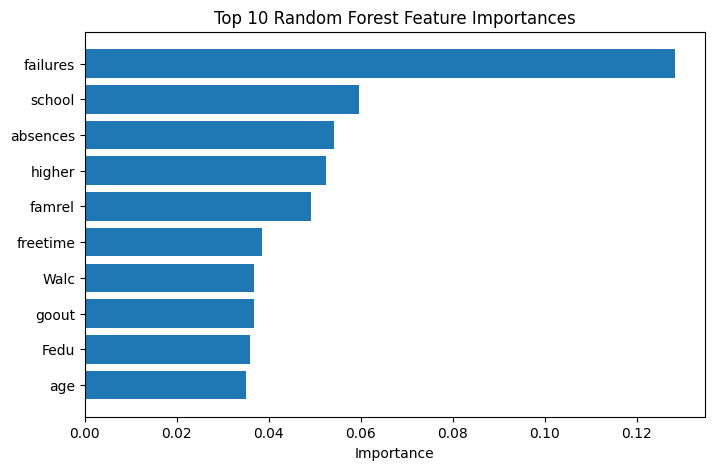

In [14]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")

plt.show()

##10. Save the results

In [15]:
random_forest_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

random_forest_results

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest,0.846154,0.5,0.05,0.090909,0.822727


In [16]:
output_path = "/content/drive/MyDrive/student-risk-ml-project/data/processed/random_forest_results.csv"

random_forest_results.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/student-risk-ml-project/data/processed/random_forest_results.csv


## ***Random Forest Summary***

A Random Forest Classifier was trained as the third model for identifying At-Risk students.

The same 80/20 stratified train-test split and `random_state=42` were used to maintain a fair comparison with Logistic Regression and Decision Tree.

Feature scaling was not applied because Random Forest is a tree-based ensemble method and is not sensitive to feature scale.

The model combined multiple decision trees to improve generalization compared with a single Decision Tree.

The model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC

Training and testing accuracy were compared to investigate overfitting.

Feature importance was also examined to identify the variables that contributed most strongly to prediction.